In [1]:
experiment_description = ("Experiment comparing the performance of low-rank vs structured sparse tensor decomposition "
                          "algorithms with different regularizations for anomaly detection in spatio-temporal data. "
                          "This experiment compares the performances on three different types of anomalies. Namely, "
                          "all of the anomalies are spatio-temporally contiguous, but they differ in their spatial shapes.\n"
                          "\t - The first type of anomaly is on an undirected 2D cartesian 7x7 grid, isotropically distributed with radius 2.\n"
                          "\t - The second type of anomaly is generated on a directed Gnm graph with 49 nodes and 80 edges. "
                            "isotropically distributed. Meaning, all nodes within radius distance are anomalous. \n"
                          "\t - The third type of anomaly is generated on a directed Gnm graph with 49 nodes and 100 edges, "
                            "anisotropically distributed. Meaning, they are generated as walks of length at most radius from center.\n"
                          "The normal part of the data is generated from a low-rank tensor of dimension (49, 50, 50), "
                          "with rank (5,5,5). The hyper-parameter search is done for 1000 anomaly case for each algorithm using "
                          "Optuna. The best hyper-parameters are used for all cases. Experiments are repeated 12 times.\n"
                          "### The independent variables:\n"
                            "\t- The type of anomaly from the three options described above\n"
                            "\t- The algorithm used for anomaly detection: [HoRPCA, LR_LOGS, LR_LOGS_VAR]\n"
                            "\t- The number of anomalies: [100, 250, 500, 1000, 2500, 5000, 7500, 10000]\n"
                          "### The dependent variables:\n"
                          "\t- AUC-ROC score\n"
                          "\t- AUC-PRC score\n"
                          "\t- Relative reconstruction error (Anomaly and Normal)\n"
                          "### The control variables:\n"
                          "\t- Group Anomaly Shape in Space: Gaussian\n"
                          "\t- Group Anomaly Amplitudes sampled from: {-1,1} Bernoulli rv with p=0.5\n"
                          "\t- Tensor dimension (49,50,50) with ranks (5,5,5).\n"
                          "\t- Radius of the anomalies: 3 for Case-1, 5 for Case-2\n"
                          "\t- Duration of the anomalies: 1\n"
                          "----------------------------------------------------------------------------\n"
                          
                          "HoRPCA parameters: mu=100, maxit=300, err_tol=1e-3\n"
                          "LR-LOGS parameters: step_size_growth=1.1, mu=100 maxit=300, err_tol=1e-3\n"
                        )
experiment_tags = {"project_name": 'Anomaly Detection Experiments',
                    "tags": 'Anomaly Detection',
                'mlflow.note.content': experiment_description}

import sys
import os
from functools import partial
from pprint import pprint

import optuna
import torch
import numpy as np
import networkx as nx
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from dask.distributed import Client, wait

module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# from src.gsp.gsp_vis import draw_graph_signal
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import hp_search_for_alg

print("Is cuda available?\t",torch.cuda.is_available())
print("How many cuda cores are available?\t",torch.cuda.device_count())

n_cores = 4
client = Client(n_workers=n_cores)
client

Is cuda available?	 False
How many cuda cores are available?	 4


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35737,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:42723,Total threads: 2
Dashboard: http://127.0.0.1:36303/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:45881,


# Case-1


In [3]:
experiment_name = 'STGAD_Exp1_Case1'
uri = "http://127.0.0.1:8087"
mlflow_param = {'experiment_name': experiment_name, 'uri': uri, 'tags': experiment_tags}

search_param = {'n_trials': 150, 'mean_over':4}
horpca_search_param = {'n_trials': 1, 'mean_over':4}
# The following is the configuration for the experiment
data_gen_param ={'lr_param': {'dim': (100, 50, 50), 'ranks': (5, 5, 5)},
                 'graph_param': {'graph_type': 'grid', 'dim': (10,10)},
                 'anomaly_param': {'NoA': 1000, 'local_dist': 'gaussian', 
                                    'time_m': 3, 'local_m': 1, 
                                    'duration': 1, 'radius': 2, 
                                    'spread': 'isotropic'}
                }
horpca_selector = {'name': 'HoRPCA','lr_modes':[1,2,3], 'verbose':0,
                    'mu':100, 'step_size_growth':1, 'maxit':100,
                    'err_tol':1e-3}

snn_logs_selector_nr1 = {'lr_modes':[1,2,3], 'graph_modes':[1], 
                      'grouping': 'neighbor', 'r_hop':1, 'weighing': 'size_normalized',
                      'verbose':0, 'mu':100, 'step_size_growth':1,
                      'maxit':100, 'err_tol':1e-4}

snn_logs_selector_nr2 = {'lr_modes':[1,2,3], 'graph_modes':[1], 
                      'grouping': 'neighbor', 'r_hop':2, 'weighing': 'size_normalized',
                      'verbose':0, 'mu':100, 'step_size_growth':1,
                      'maxit':100, 'err_tol':1e-4}

snn_logs_selector_e = {'lr_modes':[1,2,3], 'graph_modes':[1], 
                      'grouping': 'edge', 'r_hop':0, 'weighing': 'uniform',
                      'verbose':0, 'mu':100, 'step_size_growth':1,
                      'maxit':100, 'err_tol':1e-4}

# lr_logs_selector_nr1 = {'name':'LR_LOGS', 'grouping': 'neighbor', 'weighing': 'size_normalized',
#                         'r_hop': 1, 'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
#                         'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':100}

# lr_logs_selector_nr2 = {'name':'LR_LOGS', 'grouping': 'edge', 'weighing': 'uniform',
#                         'r_hop': 1, 'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
#                         'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':100}

# lr_logs_var_selector_ns10r1 = {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
#                                'var': 'S10', 'r_hop': 1, 
#                                'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
#                                'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':100}

# lr_logs_var_selector_ns11r1 = {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
#                                'var': 'S11', 'r_hop': 1, 
#                                'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
#                                'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':100}

# lr_logs_var_selector_ns10r2 = {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
#                                'var': 'S10', 'r_hop': 2, 
#                                'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
#                                'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':100}

# lr_logs_var_selector_ns11r2 = {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
#                                'var': 'S11', 'r_hop': 2, 
#                                'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
#                                'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':100}

horpca_study = hp_search_for_alg(horpca_selector, data_gen_param, horpca_search_param, mlflow_param,
                  1, log_champion=True, client=client)

# alg_selectors = [horpca_selector, lr_logs_selector_nr1, lr_logs_selector_nr2, lr_logs_var_selector_ns10r1, lr_logs_var_selector_ns11r1, lr_logs_var_selector_ns10r2, lr_logs_var_selector_ns11r2]
alg_selectors = [#horpca_selector, 
                snn_logs_selector_nr1,
                snn_logs_selector_nr2,
                snn_logs_selector_e]
studies = [horpca_study]
studies =[]
for alg_selector in alg_selectors:
    studies.append(
        hp_search_for_alg(alg_selector, data_gen_param, search_param, mlflow_param, 1, log_champion=True, client=client)
        )
    

2024-11-01 12:59:37,692 - distributed.worker - WARNING - Compute Failed
Key:       run_algorithm-b1f2d2ec30067926de156b59635d64f8
State:     executing
Function:  run_algorithm
args:      ({'lr_param': {'dim': (100, 50, 50), 'ranks': (5, 5, 5)}, 'graph_param': {'graph_type': 'grid', 'dim': (10, 10)}, 'anomaly_param': {'NoA': 1000, 'local_dist': 'gaussian', 'time_m': 3, 'local_m': 1, 'duration': 1, 'radius': 2, 'spread': 'isotropic'}}, {'name': 'HoRPCA', 'lr_modes': [1, 2, 3], 'verbose': 0, 'mu': 100, 'step_size_growth': 1, 'maxit': 100, 'err_tol': 0.001}, {'lda_nucs': [1.0, 0.00024084666430262283, 0.007362238617967569], 'lda1': 0.0433392029510173, 'rho': 0.00048124393241015474}, 0, 'cuda:0')
kwargs:    {}
Exception: "RuntimeError('The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch 

RuntimeError: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver.

Running STGAD_Exp1_grid_isotropicHoRPCA
Running STGAD_Exp1_grid_isotropicLR_LOGS_gn_wd_r1
Running STGAD_Exp1_grid_isotropicLR_LOGS_ge_wm_r1
Running STGAD_Exp1_grid_isotropicLR_LOGS_VAR_S10_gn_wd_r1
Running STGAD_Exp1_grid_isotropicLR_LOGS_VAR_S11_gn_wd_r1
Running STGAD_Exp1_grid_isotropicLR_LOGS_VAR_S10_gn_wd_r2
Running STGAD_Exp1_grid_isotropicLR_LOGS_VAR_S11_gn_wd_r2


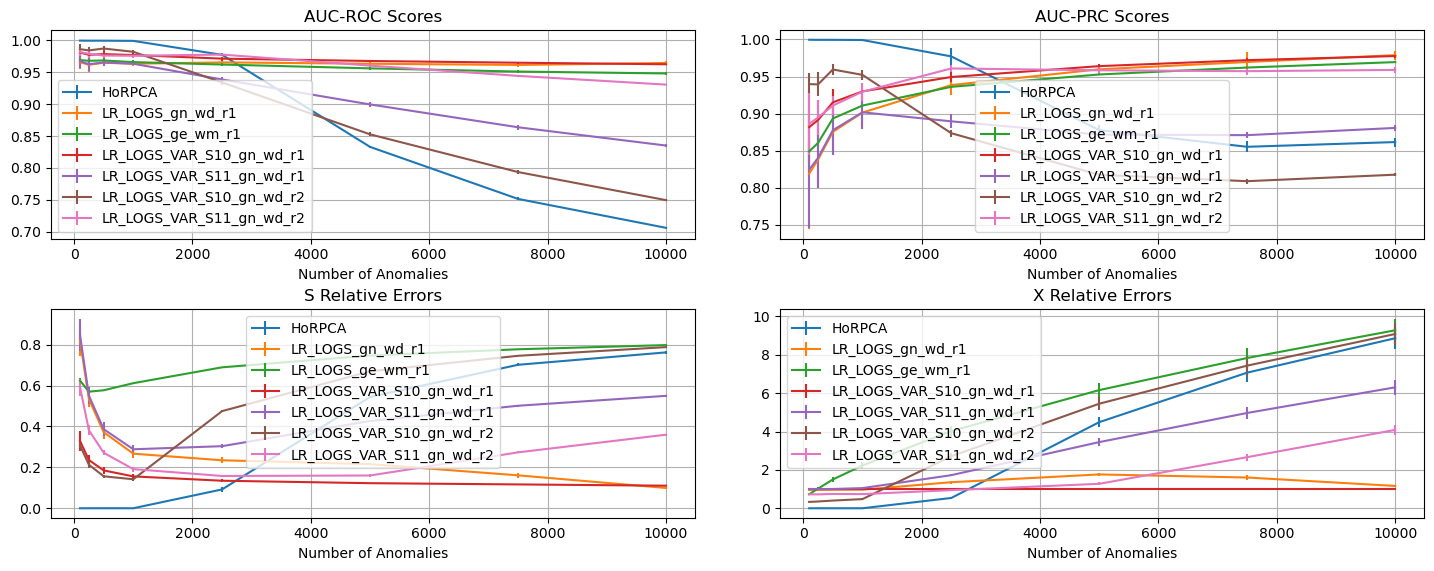

In [44]:
def plot_exp1_results(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, algorithms):
    fig, axs = plt.subplots(2, 2, figsize=(15,6))
    fig.tight_layout(pad=3.0)
    for algo in algorithms:
        axs[0,0].errorbar(NoA, np.mean(auc_roc_scores[algo], axis=1), np.std(auc_roc_scores[algo], axis=1), label=algo)
        axs[0,1].errorbar(NoA, np.mean(auc_prc_scores[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo)
        axs[1,0].errorbar(NoA, np.mean(S_rec_errors[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo)
        axs[1,1].errorbar(NoA, np.mean(X_rec_errors[algo], axis=1), np.std(X_rec_errors[algo], axis=1), label=algo)
    axs[0,0].set_title('AUC-ROC Scores')
    axs[0,1].set_title('AUC-PRC Scores')
    axs[1,0].set_title('S Relative Errors')
    axs[1,1].set_title('X Relative Errors')
    
    for ax in axs.flat:
        ax.set_xlabel('Number of Anomalies')
        ax.legend()
        ax.grid()
    return fig, axs

# Experiment 1: Case 1 (Grid 7x7, Isotropic)
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import selector_to_str
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import run_algorithm
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import get_or_create_experiment

experiment_name = mlflow_param['experiment_name']
tags = mlflow_param['tags']
experiment_id = get_or_create_experiment(experiment_name, tags)
mlflow.set_tracking_uri(uri)
mlflow.set_experiment(experiment_id=experiment_id)

NoA = [100, 250, 500, 1000, 2500, 5000, 7500, 10000]
NoT = 10

selectors = [horpca_selector] + alg_selectors
abbreviations = [selector_to_str(selector) for selector in selectors]

auc_prc_scores = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}
auc_roc_scores = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}
S_rec_errors = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}
X_rec_errors = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}

run_name = 'STGAD_Exp1_' + f'{data_gen_param["graph_param"]["graph_type"]}_{data_gen_param["anomaly_param"]["spread"]}'
with mlflow.start_run(run_name=run_name, nested=True):
    mlflow.log_params(data_gen_param['lr_param'])
    mlflow.log_params(data_gen_param['graph_param'])
    mlflow.log_params(data_gen_param['anomaly_param'])
    mlflow.set_tags({'graph_type': data_gen_param['graph_param']['graph_type'],
                     'anomaly_spread': data_gen_param['anomaly_param']['spread']})
    print("logged exp parameters")
    for i in range(len(selectors)):
        selector = selectors[i]
        alg_run_name = run_name + selector_to_str(selector)
        study = studies[i]
        best_params = max(study.best_trials, key= lambda da: da.values[0]).params
        if selector['name'] == 'HoRPCA':
            alg_param = {'lda_nucs': [1.0] + [best_params['psi_2'], best_params['psi_3']],
                            'lda1': best_params['lda1'], 'rho': best_params['rho']}
        elif selector['name']=='LR_LOGS':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho']
                            }
        elif selector['name']=='LR_LOGS_VAR':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho'],
                            'lda_1': best_params.get('lda_1',0),
                            'lda_2': best_params.get('lda_2',0),
                            'lda_t': best_params.get('lda_t',0)
                            }
        with mlflow.start_run(run_name=alg_run_name, nested=True):
            print(f"Running {alg_run_name}")
            for j, NoA_i in enumerate(NoA):
                d_gen_param ={'lr_param': {'dim': (49, 50, 50), 'ranks': (5, 5, 5)},
                        'graph_param': {'graph_type': 'grid', 'dim': (7, 7)},
                        'anomaly_param': {'NoA': NoA_i, 'local_dist': 'gaussian', 
                                            'time_m': 3, 'local_m': 1, 
                                            'duration': 1, 'radius': 2, 
                                            'spread': 'isotropic'}}
                futures = []
                n_active_task = 0
                for t in range(NoT):
                    if n_active_task == 4:
                        wait(futures)
                        n_active_task = 0
                    device = f'cuda:{n_active_task}'
                    seed = t
                    futures.append(client.submit(run_algorithm, d_gen_param, selector, alg_param,  seed, device))
                    n_active_task += 1
            
            results = client.gather(futures)
            auc_roc_scores[abbreviations[i]][j, :] = np.array([result['AUC_ROC'] for result in results])
            auc_prc_scores[abbreviations[i]][j, :] = np.array([result['AUC_PRC'] for result in results])
            S_rec_errors[abbreviations[i]][j, :] = np.array([result['S_relative_error'] for result in results])
            X_rec_errors[abbreviations[i]][j, :] = np.array([result['X_relative_error'] for result in results])

            mlflow.log_metrics({'AUC_ROC': np.mean(auc_roc_scores[abbreviations[i]], axis=1), 'AUC_ROC_std': np.std(auc_roc_scores[abbreviations[i]], axis=1),
                                'AUC_PRC': np.mean(auc_prc_scores[abbreviations[i]], axis=1), 'AUC_PRC_std': np.std(auc_prc_scores[abbreviations[i]], axis=1),
                                'S_relative_error': np.mean(S_rec_errors[abbreviations[i]], axis=1), 'S_relative_error_std': np.std(S_rec_errors[abbreviations[i]], axis=1),
                                'X_relative_error': np.mean(X_rec_errors[abbreviations[i]], axis=1), 'X_relative_error_std': np.std(X_rec_errors[abbreviations[i]], axis=1)
                                })
    fig, axs = plot_exp1_results(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, abbreviations)
    mlflow.log_artifact(fig, 'AUC_ROC_AUC_PRC_S_X_Relative_Errors.png')
    

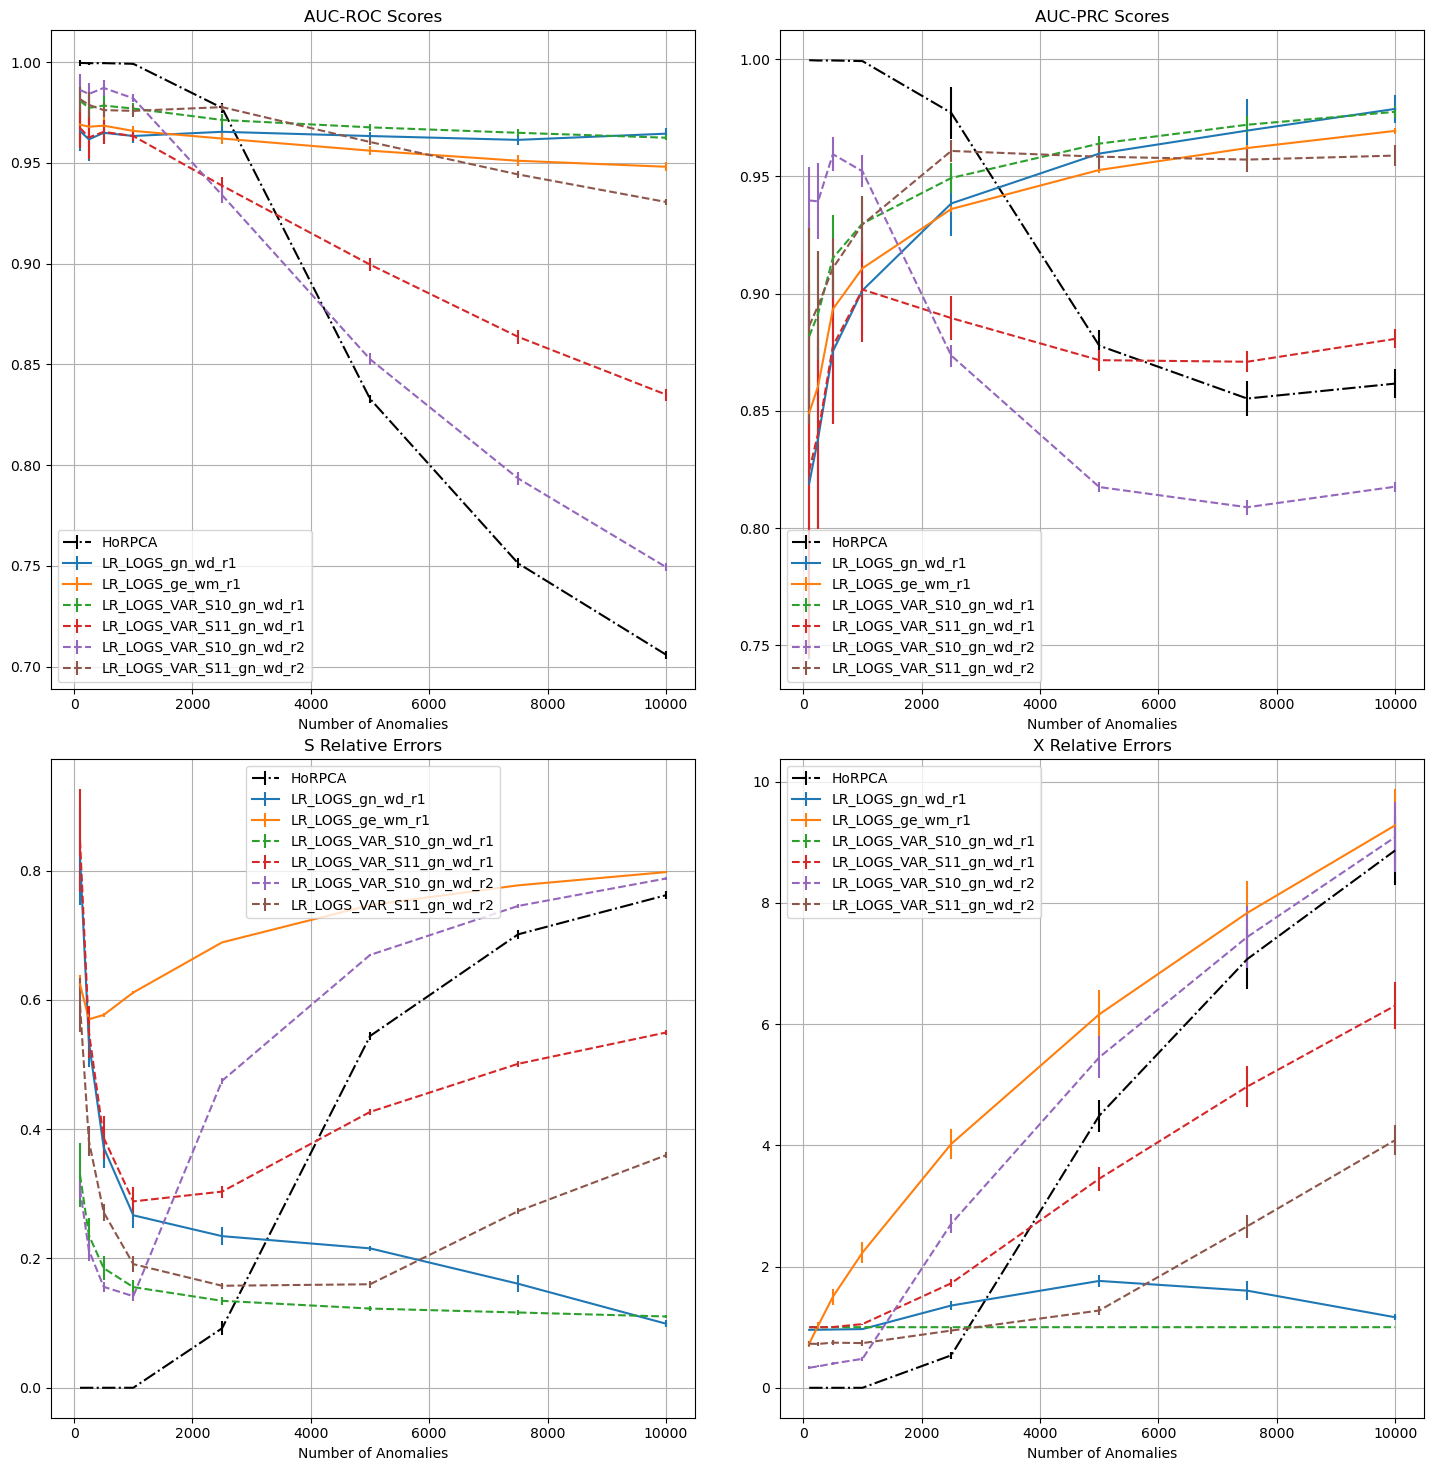

In [47]:
def plot_exp1_results(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, algorithms):
    fig, axs = plt.subplots(2, 2, figsize=(15,15))
    fig.tight_layout(pad=3.0)
    for algo in algorithms:
        color = None
        if 'VAR' in algo:
            linestyle = '--'
        elif algo == 'HoRPCA':
            linestyle = '-.'
            color = 'black'
        else:
            linestyle = '-'
            
        axs[0,0].errorbar(NoA, np.mean(auc_roc_scores[algo], axis=1), np.std(auc_roc_scores[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[0,1].errorbar(NoA, np.mean(auc_prc_scores[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,0].errorbar(NoA, np.mean(S_rec_errors[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,1].errorbar(NoA, np.mean(X_rec_errors[algo], axis=1), np.std(X_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
    axs[0,0].set_title('AUC-ROC Scores')
    axs[0,1].set_title('AUC-PRC Scores')
    axs[1,0].set_title('S Relative Errors')
    axs[1,1].set_title('X Relative Errors')
    
    for ax in axs.flat:
        ax.set_xlabel('Number of Anomalies')
        ax.legend()
        ax.grid()
    return fig, axs

fig, axs = plot_exp1_results(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, abbreviations)

# Case 2:


Ratio of non-zero entries for case-2:  0.0732
Ratio of non-zero entries for case-1:  0.07992571428571428


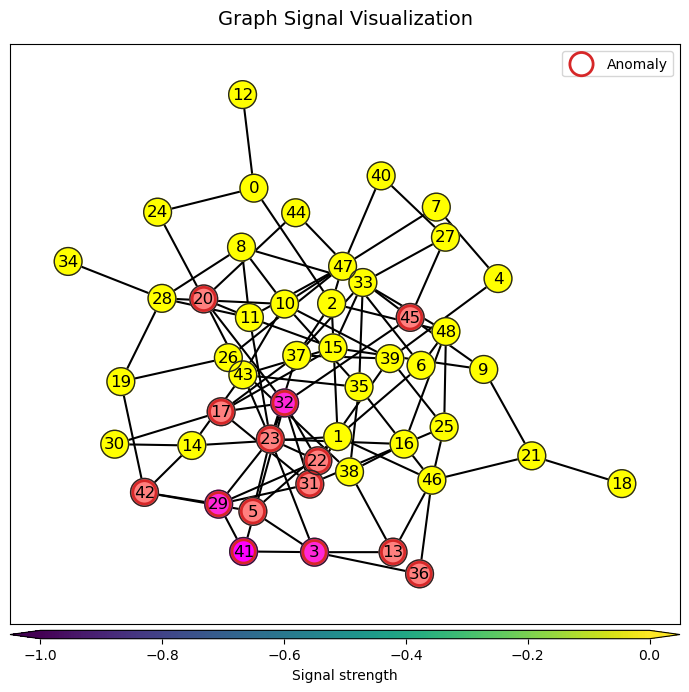

True

In [55]:
from src.gsp.gsp_vis import draw_graph_signal
from src.synthetic_data.generate_anomaly import generate_spatio_temporal_anomaly

n = 49
m = 100
graph_seed = 2
anomaly_seed = 0
distribution = 'bernoulli'
anomaly_spread = 'anisotropic'
local_distribution = 'gaussian'
radius = 9
non_zero = 0
Gnm = nx.gnm_random_graph(n, m, seed=graph_seed, directed=False)
for i in range(20):
    a_nm_e, am_nm_e = generate_spatio_temporal_anomaly((49, 50, 50), Gnm, 1000, 
                                                    time_m=3, local_m=1, duration=1, 
                                                    radius=radius, seed=i,
                                                    local_dist=local_distribution,
                                                    distribution=distribution, 
                                                    anomaly_spread=anomaly_spread)
    non_zero += np.sum(am_nm_e!=0)
print("Ratio of non-zero entries for case-2: ",non_zero/(20*49*50*50))

G = nx.grid_2d_graph(7,7)
non_zero = 0
distribution = 'bernoulli'
anomaly_spread = 'isotropic'
# local_distribution = 'gaussian'
radius = 2
for i in range(20):
    a_nm_e, am_nm_e = generate_spatio_temporal_anomaly((49, 50, 50), G, 1000, 
                                                    time_m=3, local_m=1, duration=1, 
                                                    radius=radius, seed=i,
                                                    local_dist=local_distribution,
                                                    distribution=distribution, 
                                                    anomaly_spread=anomaly_spread)
    non_zero += np.sum(am_nm_e!=0)
print("Ratio of non-zero entries for case-1: ",non_zero/(20*49*50*50))
# Gnm = nx.gnm_random_graph(n, m, seed=graph_seed, directed=False)
# NoA = [100, 250, 500, 1000, 2500, 5000, 7500, 10000]
# a_nm_e, am_nm_e = generate_spatio_temporal_anomaly((49, 1, 1), Gnm, 1,
#                                                     time_m=3, local_m=1, duration=1,
#                                                     radius=radius, seed=anomaly_seed, local_dist=local_distribution,
#                                                     distribution=distribution, anomaly_spread=anomaly_spread)

a_nm_e, am_nm_e = generate_spatio_temporal_anomaly((49, 1, 1), Gnm, 1,
                                                    time_m=3, local_m=1, duration=1,
                                                    radius=radius, seed=anomaly_seed, local_dist=local_distribution,
                                                    distribution=distribution, anomaly_spread=anomaly_spread)
draw_graph_signal(Gnm, a_nm_e.ravel(), anomaly_labels=am_nm_e.ravel(), figsize=(7,7))
nx.is_connected(Gnm)

In [3]:
experiment_name = 'STGAD_Exp1_Case2'
uri = "http://127.0.0.1:8080"
mlflow_param = {'experiment_name': experiment_name, 'uri': uri, 'tags': experiment_tags}

search_param = {'n_trials': 300, 'mean_over':4}
# The following is the configuration for the experiment
data_gen_param ={'lr_param': {'dim': (49, 50, 50), 'ranks': (5, 5, 5)},
                 'graph_param': {'graph_type': 'Gnm', 'n': 49, 'm': 100, 
                                'directed':False, 
                                'seed':2},
                 'anomaly_param': {'NoA': 500, 'local_dist': 'gaussian', 
                                    'time_m': 3, 'local_m': 1, 
                                    'duration': 1, 'radius': 9, 
                                    'spread': 'anisotropic'}
                }
selectors = []
selectors.append( {'name': 'HoRPCA','lr_modes':[1,2,3], 'verbose':0,
                    'mu':100, 'step_size_growth':1, 'maxit':80,
                    'err_tol':1e-3})


selectors.append( {'name':'LR_LOGS', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                        'r_hop': 1, 'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                        'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS', 'grouping': 'edge', 'weighing': 'uniform',
                        'r_hop': 1, 'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                        'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append(  {'name':'LR_LOGS', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                        'r_hop': 2, 'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                        'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S10', 'r_hop': 1, 
                               'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S11', 'r_hop': 1, 
                               'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append(  {'name':'LR_LOGS_VAR', 'grouping': 'edge', 'weighing': 'size_normalized',
                               'var': 'S01', 'r_hop': 1, 
                               'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append(  {'name':'LR_LOGS_VAR', 'grouping': 'edge', 'weighing': 'size_normalized',
                               'var': 'S10', 'r_hop': 1, 
                               'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append(  {'name':'LR_LOGS_VAR', 'grouping': 'edge', 'weighing': 'size_normalized',
                               'var': 'S11', 'r_hop': 1, 
                               'lr_modes':[1,2,3], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})


studies = []
for alg_selector in selectors:
    studies.append(
        hp_search_for_alg(alg_selector, data_gen_param, search_param, mlflow_param, 1, log_champion=True, client=client)
        )
    

HoRPCA
Trial 0 achieved AUC-ROC= 0.97225, AUC-PRC= 0.89821
{'lda1': 1.077762127814653e-05,
 'psi_2': 0.10226947041709748,
 'psi_3': 4.350012398372192,
 'rho': 0.15838502176011876}
HoRPCA
Trial 8 achieved AUC-ROC= 0.97259, AUC-PRC= 0.89726,  with 0.035% and 0.106% improvement.
{'lda1': 0.00020036337572034221,
 'psi_2': 173.90003255330774,
 'psi_3': 16.111616837860865,
 'rho': 0.08401366460557765}
HoRPCA
Trial 12 achieved AUC-ROC= 0.97331, AUC-PRC= 0.89749,  with 0.074% and 0.025% improvement.
{'lda1': 0.0018817282411485716,
 'psi_2': 368.800882787988,
 'psi_3': 1.058115764468097,
 'rho': 0.0024673806520622067}
HoRPCA
Trial 30 achieved AUC-ROC= 0.99166, AUC-PRC= 0.99159,  with 1.851% and 9.490% improvement.
{'lda1': 0.16802507286872734,
 'psi_2': 0.0022691483274227893,
 'psi_3': 0.00031319809062643625,
 'rho': 0.33484302259120424}
HoRPCA
Trial 59 achieved AUC-ROC= 0.99307, AUC-PRC= 0.99332,  with 0.141% and 0.175% improvement.
{'lda1': 0.3138316139536441,
 'psi_2': 1.4470610041018581,
 '

logged exp parameters
Running STGAD_Exp1Gnm_anisotropicHoRPCA
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_gn_wd_r1
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_ge_wm_r1
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_gn_wd_r2
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_VAR_S10_gn_wd_r1
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_VAR_S11_gn_wd_r1
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_VAR_S01_ge_wd_r1
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_VAR_S10_ge_wd_r1
Running STGAD_Exp1Gnm_anisotropicLR_LOGS_VAR_S11_ge_wd_r1


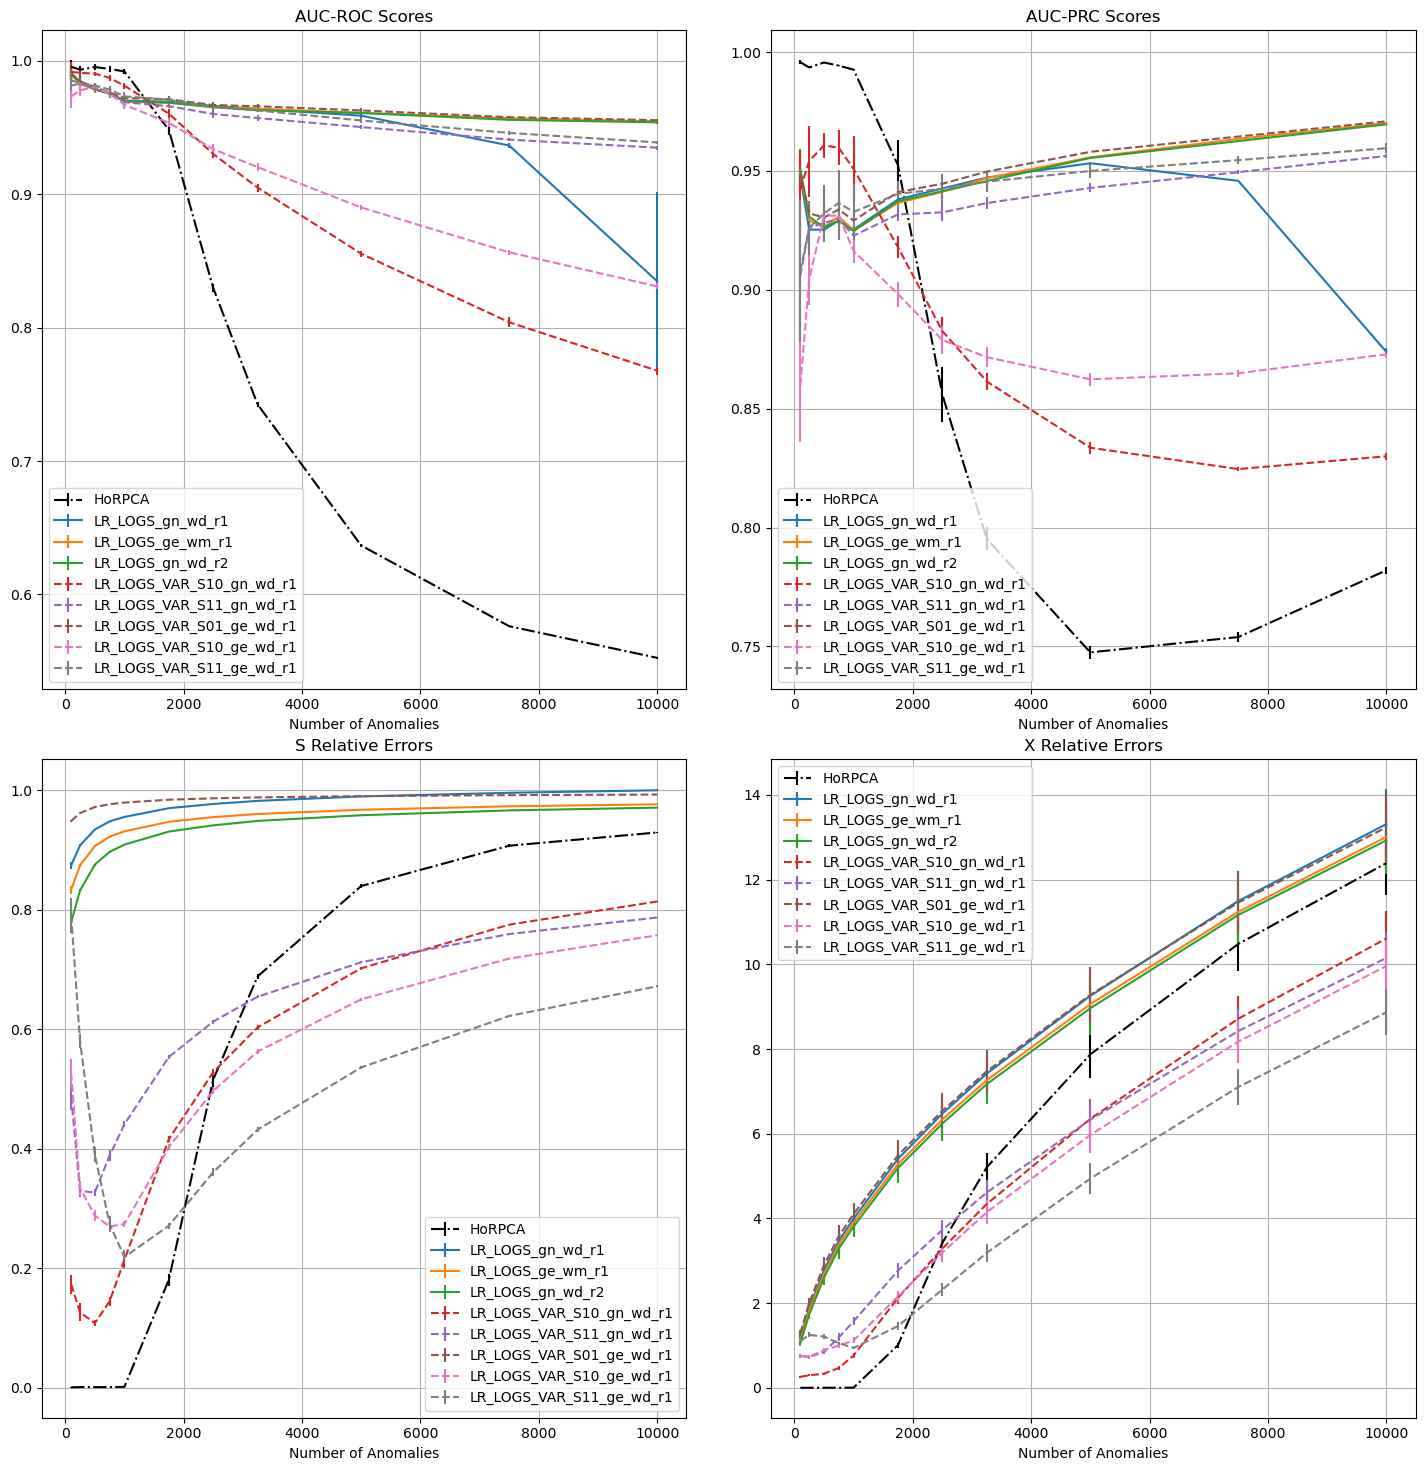

In [16]:
def plot_exp1_results(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, algorithms):
    fig, axs = plt.subplots(2, 2, figsize=(15,15))
    fig.tight_layout(pad=3.0)
    for algo in algorithms:
        color = None
        if 'VAR' in algo:
            linestyle = '--'
        elif algo == 'HoRPCA':
            linestyle = '-.'
            color = 'black'
        else:
            linestyle = '-'
            
        axs[0,0].errorbar(NoA, np.mean(auc_roc_scores[algo], axis=1), np.std(auc_roc_scores[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[0,1].errorbar(NoA, np.mean(auc_prc_scores[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,0].errorbar(NoA, np.mean(S_rec_errors[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,1].errorbar(NoA, np.mean(X_rec_errors[algo], axis=1), np.std(X_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
    axs[0,0].set_title('AUC-ROC Scores')
    axs[0,1].set_title('AUC-PRC Scores')
    axs[1,0].set_title('S Relative Errors')
    axs[1,1].set_title('X Relative Errors')
    
    for ax in axs.flat:
        ax.set_xlabel('Number of Anomalies')
        ax.legend()
        ax.grid()
    return fig, axs

from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import selector_to_str
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import run_algorithm
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import get_or_create_experiment

experiment_name = mlflow_param['experiment_name']
tags = mlflow_param['tags']
experiment_id = get_or_create_experiment(experiment_name, tags)
mlflow.set_tracking_uri(uri)
mlflow.set_experiment(experiment_id=experiment_id)
data_gen_param ={'lr_param': {'dim': (49, 50, 50), 'ranks': (5, 5, 5)},
                 'graph_param': {'graph_type': 'Gnm', 'n': 49, 'm': 100, 
                                'directed':False, 
                                'seed':2},
                 'anomaly_param': {'NoA': 500, 'local_dist': 'gaussian', 
                                    'time_m': 3, 'local_m': 1, 
                                    'duration': 1, 'radius': 9, 
                                    'spread': 'anisotropic'}
                }
NoA = [100, 250, 500, 750, 1000, 1750, 2500, 3250, 5000, 7500, 10000]
NoT = 8

abbreviations = [selector_to_str(selector) for selector in selectors]

auc_prc_scores = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}
auc_roc_scores = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}
S_rec_errors = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}
X_rec_errors = {abbr: np.zeros((len(NoA), NoT)) for abbr in abbreviations}

run_name = 'STGAD_Exp1' + f'{data_gen_param["graph_param"]["graph_type"]}_{data_gen_param["anomaly_param"]["spread"]}'
with mlflow.start_run(run_name=run_name, nested=True):
    mlflow.log_params(data_gen_param['lr_param'])
    mlflow.log_params(data_gen_param['graph_param'])
    mlflow.log_params(data_gen_param['anomaly_param'])
    mlflow.set_tags({'graph_type': data_gen_param['graph_param']['graph_type'],
                     'anomaly_spread': data_gen_param['anomaly_param']['spread']})
    print("logged exp parameters")
    for i in range(len(selectors)):
        selector = selectors[i]
        alg_run_name = run_name + selector_to_str(selector)
        study = studies[i]
        best_params = max(study.best_trials, key= lambda da: da.values[0]).params
        if selector['name'] == 'HoRPCA':
            alg_param = {'lda_nucs': [1.0] + [best_params['psi_2'], best_params['psi_3']],
                            'lda1': best_params['lda1'], 'rho': best_params['rho']}
        elif selector['name']=='LR_LOGS':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho']
                            }
        elif selector['name']=='LR_LOGS_VAR':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho'],
                            'lda_1': best_params.get('lda_1',0),
                            'lda_2': best_params.get('lda_2',0),
                            'lda_t': best_params.get('lda_t',0)
                            }
        with mlflow.start_run(run_name=alg_run_name, nested=True):
            print(f"Running {alg_run_name}")
            for j, NoA_i in enumerate(NoA):
                d_gen_param = data_gen_param.copy()
                d_gen_param['anomaly_param']['NoA'] = NoA_i
                futures = []
                n_active_task = 0
                for t in range(NoT):
                    if n_active_task == 4:
                        wait(futures)
                        n_active_task = 0
                    device = f'cuda:{n_active_task}'
                    seed = t + 32132
                    futures.append(client.submit(run_algorithm, d_gen_param, selector, alg_param,  seed, device))
                    n_active_task += 1
            
                results = client.gather(futures)
                auc_roc_scores[abbreviations[i]][j, :] = np.array([result['AUC_ROC'] for result in results])
                auc_prc_scores[abbreviations[i]][j, :] = np.array([result['AUC_PRC'] for result in results])
                S_rec_errors[abbreviations[i]][j, :] = np.array([result['S_relative_error'] for result in results])
                X_rec_errors[abbreviations[i]][j, :] = np.array([result['X_relative_error'] for result in results])
    fig, axs = plot_exp1_results(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, abbreviations)
    mlflow.log_figure(fig, 'AUC_ROC_AUC_PRC_S_X_Relative_Errors.png')

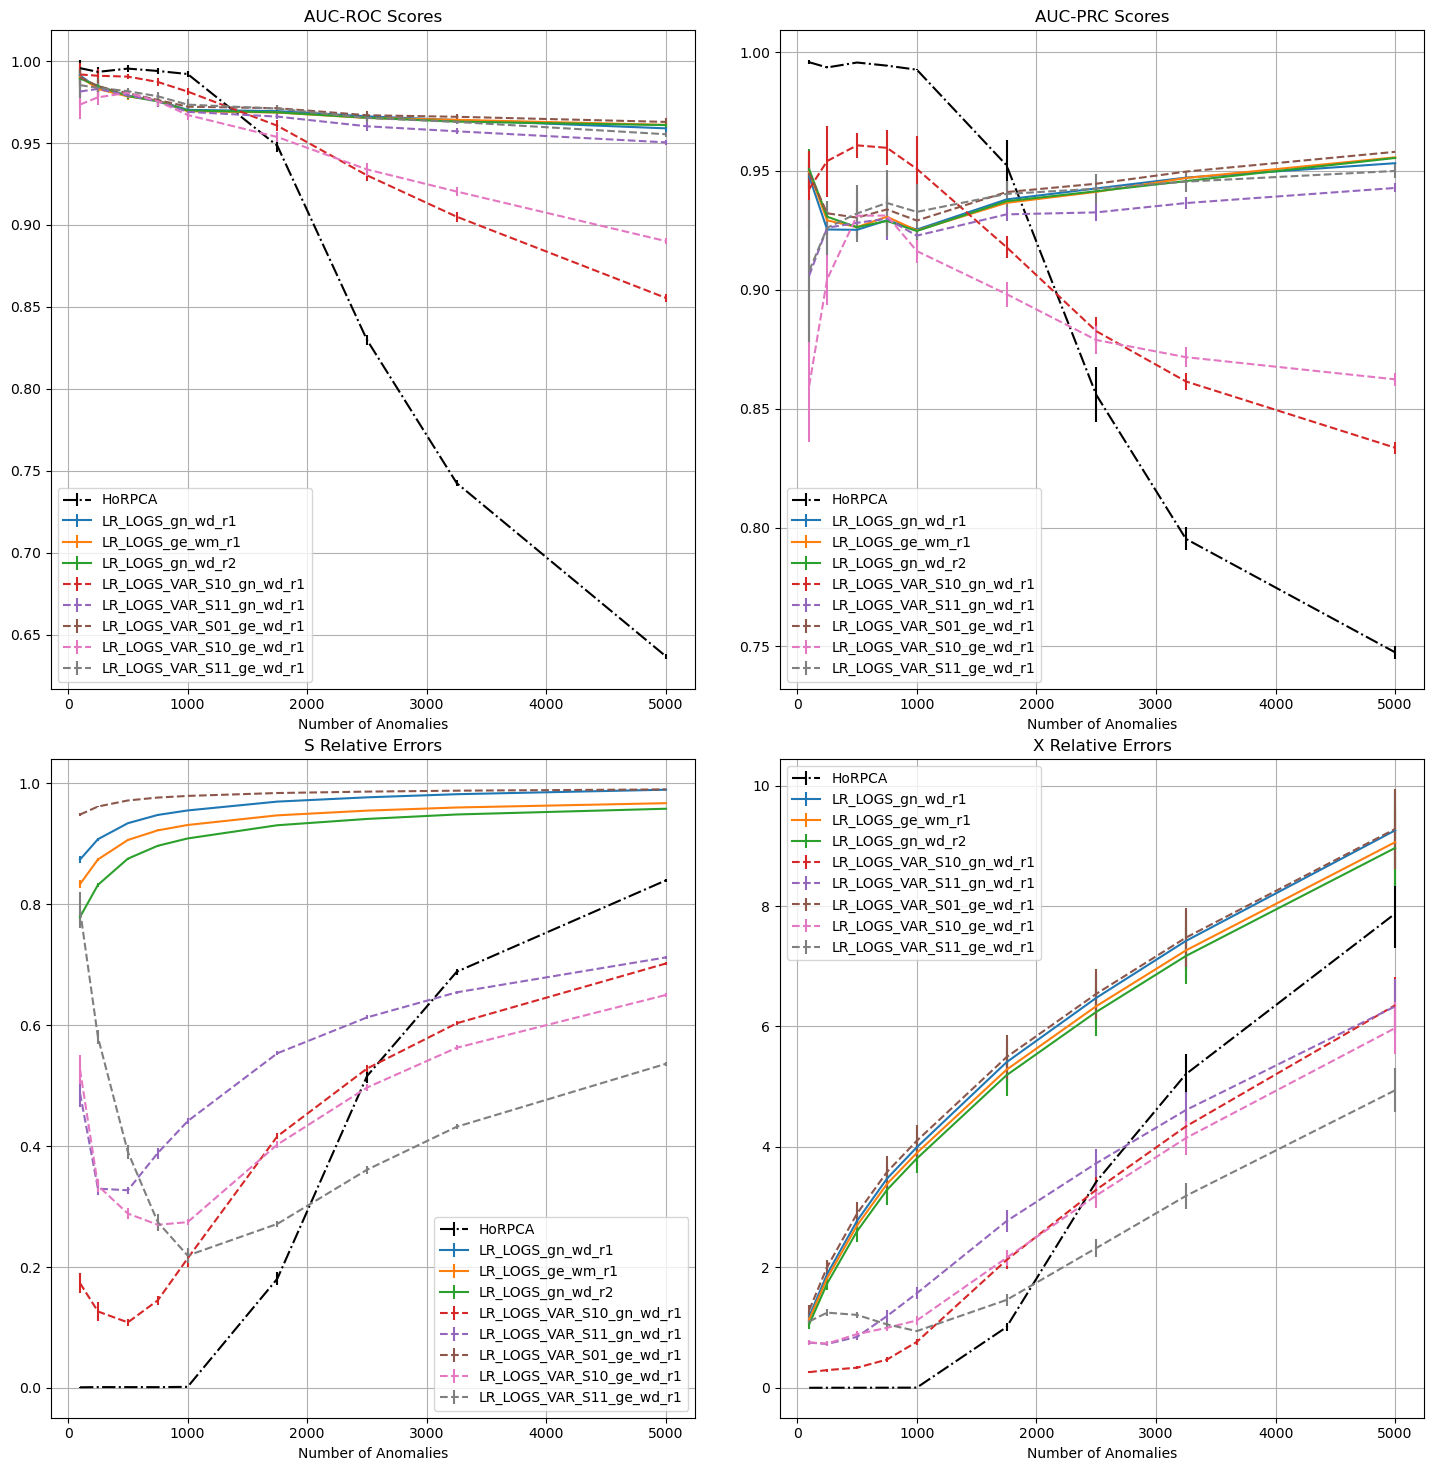

In [18]:
def plot_exp1_results2(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, algorithms):
    fig, axs = plt.subplots(2, 2, figsize=(15,15))
    fig.tight_layout(pad=3.0)
    for algo in algorithms:
        color = None
        if 'VAR' in algo:
            linestyle = '--'
        elif algo == 'HoRPCA':
            linestyle = '-.'
            color = 'black'
        else:
            linestyle = '-'
            
        axs[0,0].errorbar(NoA[:-2], np.mean(auc_roc_scores[algo][:-2], axis=1), np.std(auc_roc_scores[algo][:-2], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[0,1].errorbar(NoA[:-2], np.mean(auc_prc_scores[algo][:-2], axis=1), np.std(S_rec_errors[algo][:-2], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,0].errorbar(NoA[:-2], np.mean(S_rec_errors[algo][:-2], axis=1), np.std(S_rec_errors[algo][:-2], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,1].errorbar(NoA[:-2], np.mean(X_rec_errors[algo][:-2], axis=1), np.std(X_rec_errors[algo][:-2], axis=1), label=algo, linestyle=linestyle, color=color)
    axs[0,0].set_title('AUC-ROC Scores')
    axs[0,1].set_title('AUC-PRC Scores')
    axs[1,0].set_title('S Relative Errors')
    axs[1,1].set_title('X Relative Errors')
    
    for ax in axs.flat:
        ax.set_xlabel('Number of Anomalies')
        ax.legend()
        ax.grid()
    return fig, axs

fig, axs = plot_exp1_results2(NoA, auc_roc_scores, S_rec_errors, X_rec_errors, abbreviations)

logged exp parameters
Running STGAD_Exp2_3_Gnm_anisotropicHoRPCA
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_gn_wd_r1
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_ge_wm_r1
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_gn_wd_r2
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_VAR_S10_gn_wd_r1
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_VAR_S11_gn_wd_r1
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_VAR_S01_ge_wd_r1
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_VAR_S10_ge_wd_r1
Running STGAD_Exp2_3_Gnm_anisotropicLR_LOGS_VAR_S11_ge_wd_r1


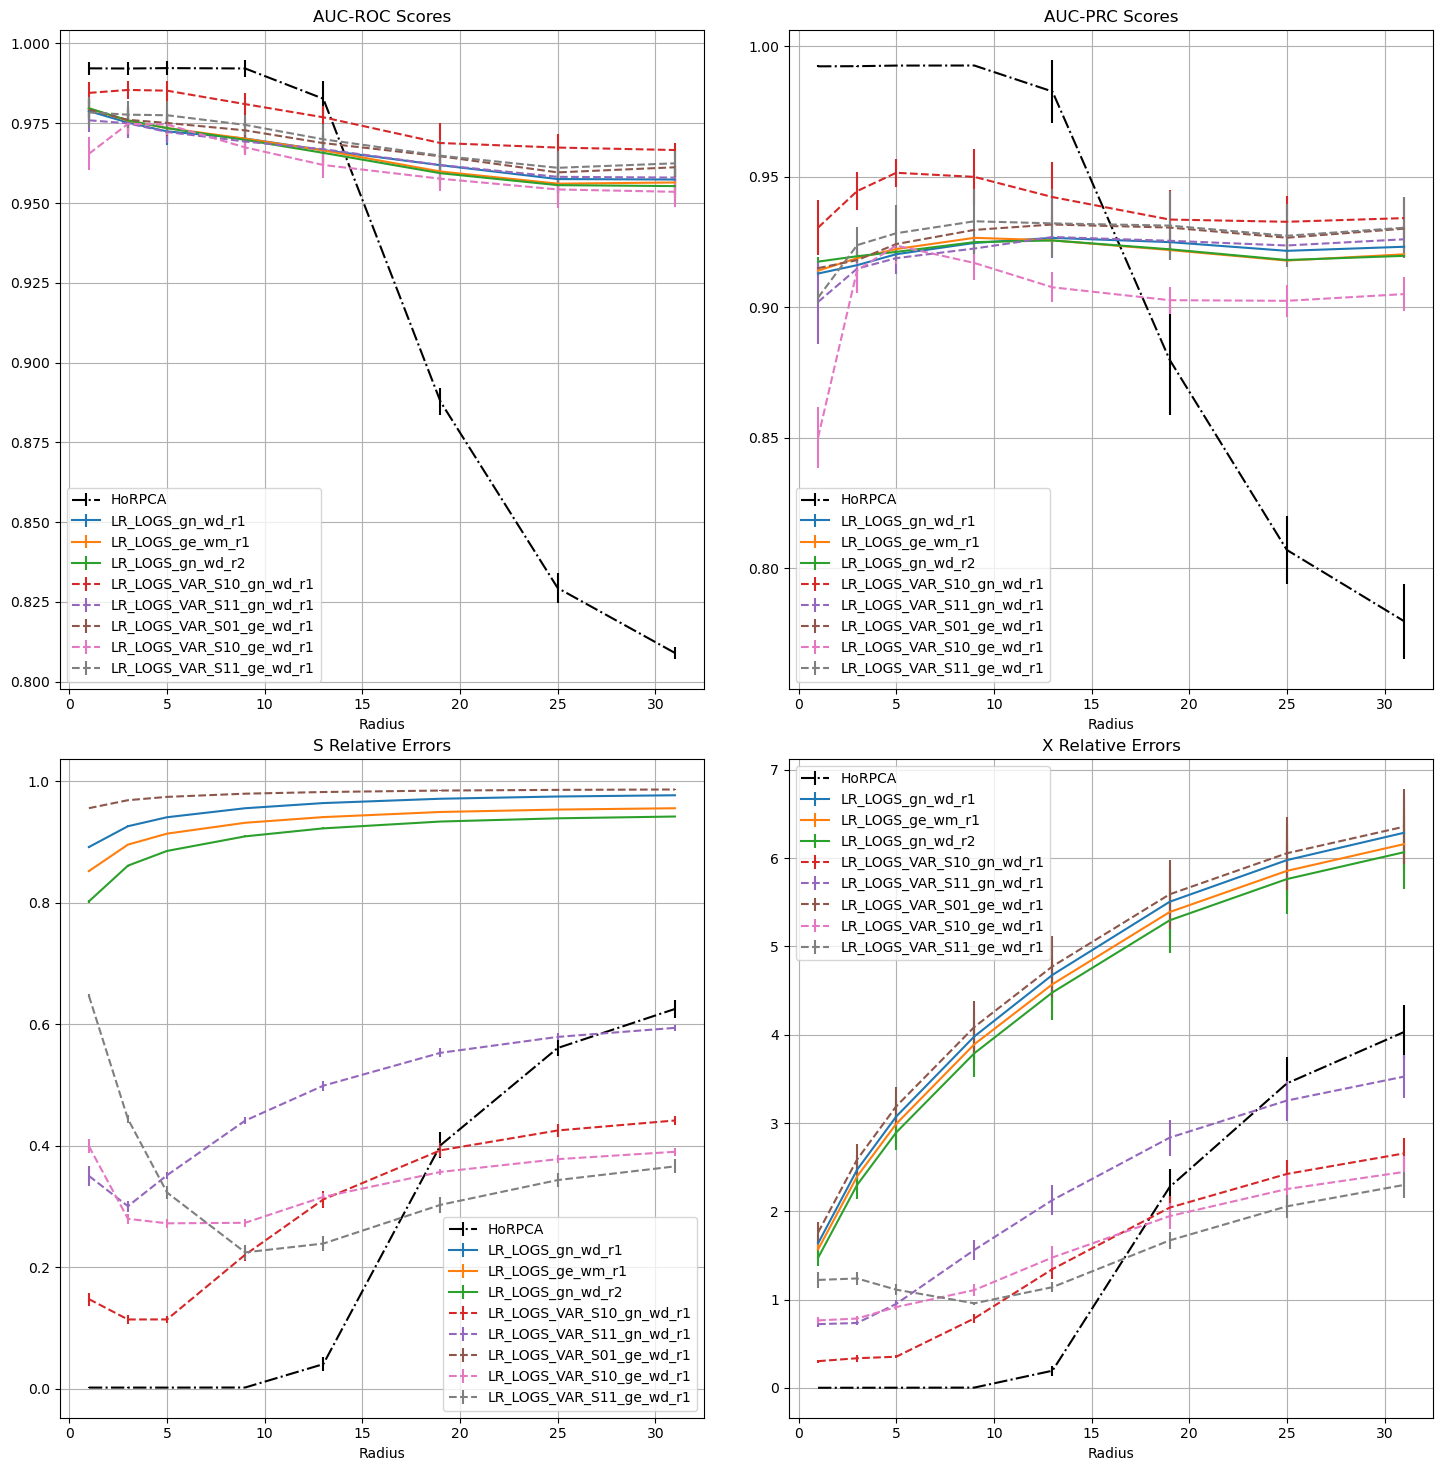

In [28]:
def plot_exp2_results(radius, auc_roc_scores, S_rec_errors, X_rec_errors, algorithms):
    fig, axs = plt.subplots(2, 2, figsize=(15,15))
    fig.tight_layout(pad=3.0)
    for algo in algorithms:
        color = None
        if 'VAR' in algo:
            linestyle = '--'
        elif algo == 'HoRPCA':
            linestyle = '-.'
            color = 'black'
        else:
            linestyle = '-'
            
        axs[0,0].errorbar(radius, np.mean(auc_roc_scores[algo], axis=1), np.std(auc_roc_scores[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[0,1].errorbar(radius, np.mean(auc_prc_scores[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,0].errorbar(radius, np.mean(S_rec_errors[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,1].errorbar(radius, np.mean(X_rec_errors[algo], axis=1), np.std(X_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
    axs[0,0].set_title('AUC-ROC Scores')
    axs[0,1].set_title('AUC-PRC Scores')
    axs[1,0].set_title('S Relative Errors')
    axs[1,1].set_title('X Relative Errors')
    
    for ax in axs.flat:
        ax.set_xlabel('Radius')
        ax.legend()
        ax.grid()
    return fig, axs

from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import selector_to_str
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import run_algorithm
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import get_or_create_experiment

experiment_name = 'STGAD_Exp2_Case2'
uri = "http://127.0.0.1:8080"
mlflow_param = {'experiment_name': experiment_name, 'uri': uri, 'tags': experiment_tags}

search_param = {'n_trials': 300, 'mean_over':4}
# The following is the configuration for the experiment
data_gen_param ={'lr_param': {'dim': (49, 50, 50), 'ranks': (5, 5, 5)},
                 'graph_param': {'graph_type': 'Gnm', 'n': 49, 'm': 100, 
                                'directed':False, 
                                'seed':2},
                 'anomaly_param': {'NoA': 1000, 'local_dist': 'gaussian', 
                                    'time_m': 3, 'local_m': 1, 
                                    'duration': 1, 'radius': 9, 
                                    'spread': 'anisotropic'}
                }

experiment_name = mlflow_param['experiment_name']
tags = mlflow_param['tags']
experiment_id = get_or_create_experiment(experiment_name, tags)
mlflow.set_tracking_uri(uri)
mlflow.set_experiment(experiment_id=experiment_id)

radius = [1,3,5,9,13,19,25,31]
NoT = 4

abbreviations = [selector_to_str(selector) for selector in selectors]

auc_prc_scores = {abbr: np.zeros((len(radius), NoT)) for abbr in abbreviations}
auc_roc_scores = {abbr: np.zeros((len(radius), NoT)) for abbr in abbreviations}
S_rec_errors = {abbr: np.zeros((len(radius), NoT)) for abbr in abbreviations}
X_rec_errors = {abbr: np.zeros((len(radius), NoT)) for abbr in abbreviations}

run_name = 'STGAD_Exp2_3_' + f'{data_gen_param["graph_param"]["graph_type"]}_{data_gen_param["anomaly_param"]["spread"]}'
with mlflow.start_run(run_name=run_name, nested=True):
    mlflow.log_params(data_gen_param['lr_param'])
    mlflow.log_params(data_gen_param['graph_param'])
    mlflow.log_params(data_gen_param['anomaly_param'])
    mlflow.set_tags({'graph_type': data_gen_param['graph_param']['graph_type'],
                     'anomaly_spread': data_gen_param['anomaly_param']['spread']})
    print("logged exp parameters")
    for i in range(len(selectors)):
        selector = selectors[i]
        alg_run_name = run_name + selector_to_str(selector)
        study = studies[i]
        best_params = max(study.best_trials, key= lambda da: da.values[0]).params
        if selector['name'] == 'HoRPCA':
            alg_param = {'lda_nucs': [1.0] + [best_params['psi_2'], best_params['psi_3']],
                            'lda1': best_params['lda1'], 'rho': best_params['rho']}
        elif selector['name']=='LR_LOGS':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho']
                            }
        elif selector['name']=='LR_LOGS_VAR':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho'],
                            'lda_1': best_params.get('lda_1',0),
                            'lda_2': best_params.get('lda_2',0),
                            'lda_t': best_params.get('lda_t',0)
                            }
        with mlflow.start_run(run_name=alg_run_name, nested=True):
            print(f"Running {alg_run_name}")
            for j, radius_i in enumerate(radius):
                d_gen_param = data_gen_param.copy()
                d_gen_param['anomaly_param']['radius'] = radius_i
                futures = []
                n_active_task = 0
                for t in range(NoT):
                    if n_active_task == 4:
                        wait(futures)
                        n_active_task = 0
                    device = f'cuda:{n_active_task}'
                    seed = t + 32132
                    futures.append(client.submit(run_algorithm, d_gen_param, selector, alg_param,  seed, device))
                    n_active_task += 1
            
                results = client.gather(futures)
                auc_roc_scores[abbreviations[i]][j, :] = np.array([result['AUC_ROC'] for result in results])
                auc_prc_scores[abbreviations[i]][j, :] = np.array([result['AUC_PRC'] for result in results])
                S_rec_errors[abbreviations[i]][j, :] = np.array([result['S_relative_error'] for result in results])
                X_rec_errors[abbreviations[i]][j, :] = np.array([result['X_relative_error'] for result in results])
    fig, axs = plot_exp2_results(radius, auc_roc_scores, S_rec_errors, X_rec_errors, abbreviations)
    mlflow.log_figure(fig, 'AUC_ROC_AUC_PRC_S_X_Relative_Errors.png')

logged exp parameters
Running STGAD_Exp3_Gnm_anisotropicHoRPCA
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_gn_wd_r1
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_ge_wm_r1
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_gn_wd_r2
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_VAR_S10_gn_wd_r1
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_VAR_S11_gn_wd_r1
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_VAR_S01_ge_wd_r1
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_VAR_S10_ge_wd_r1
Running STGAD_Exp3_Gnm_anisotropicLR_LOGS_VAR_S11_ge_wd_r1


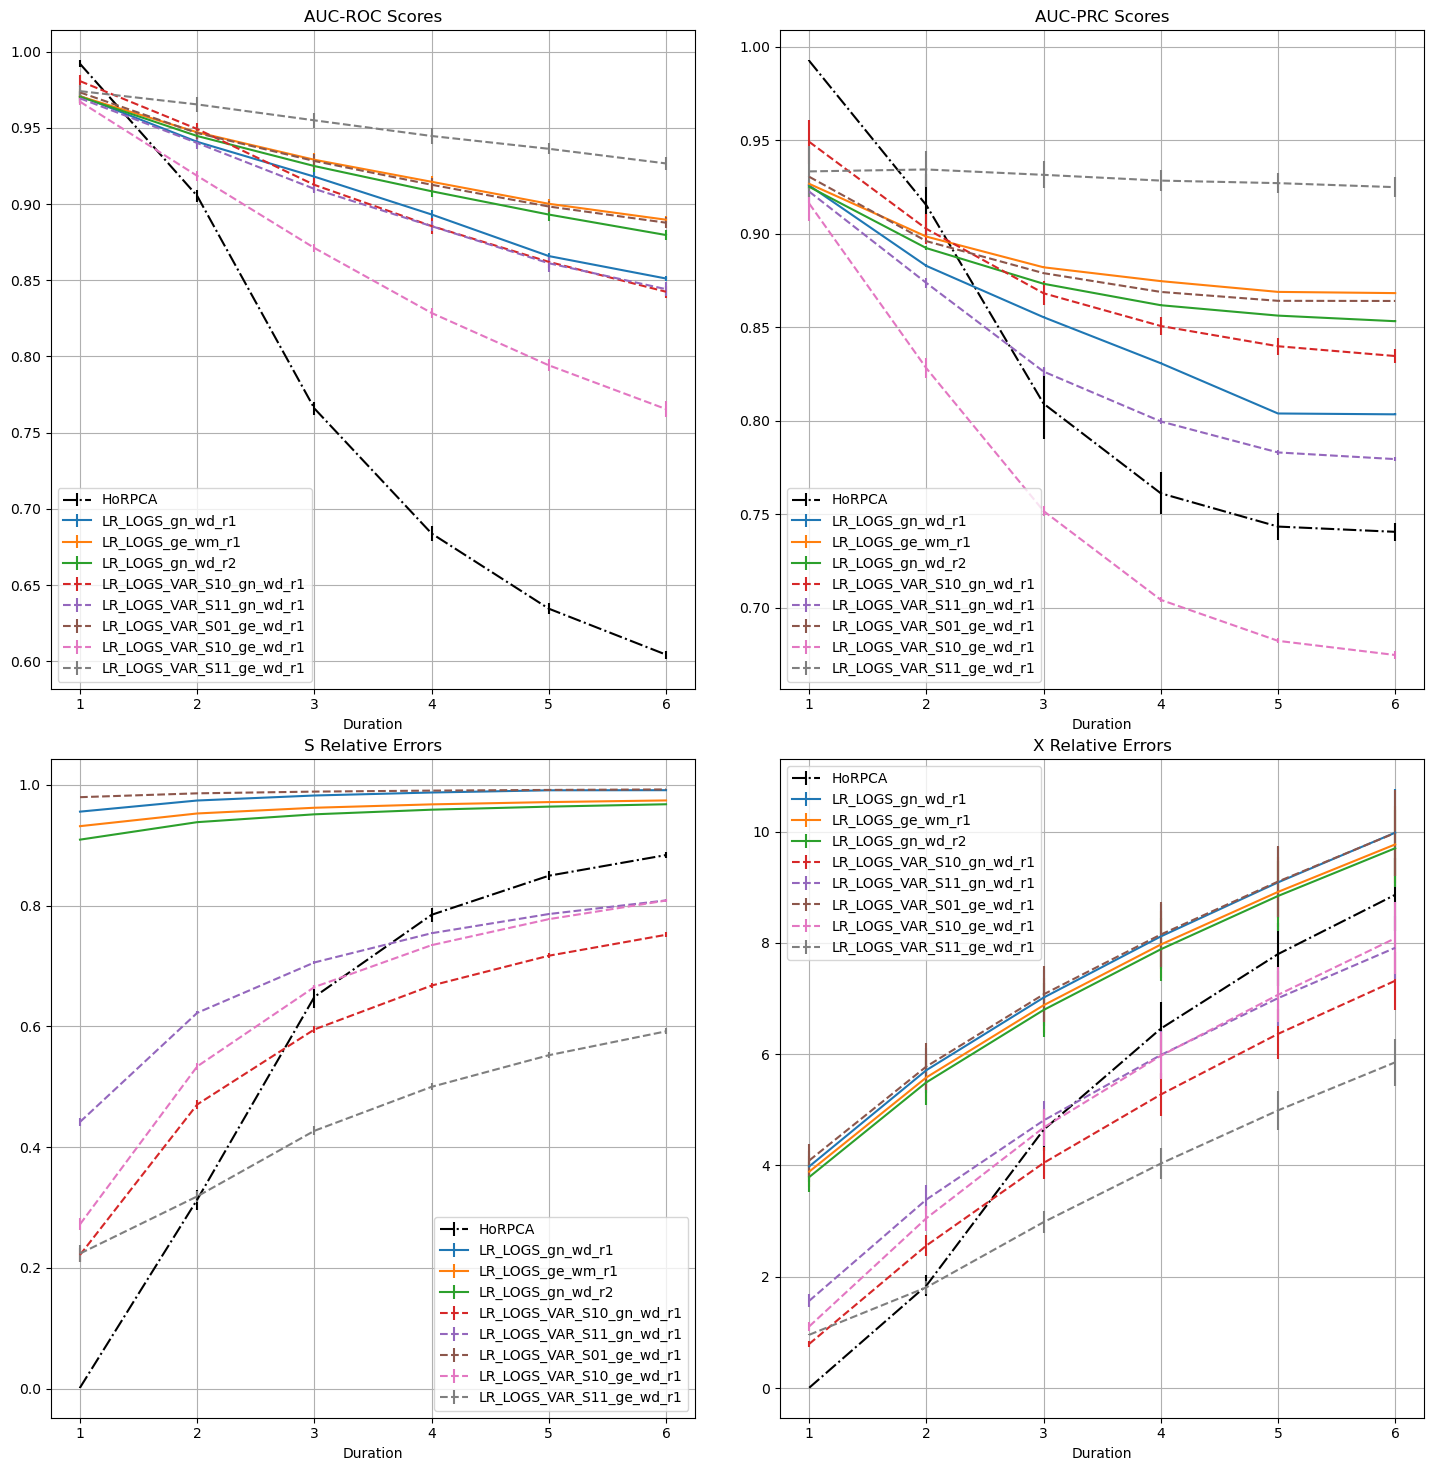

In [31]:
def plot_exp2_results(radius, auc_roc_scores, S_rec_errors, X_rec_errors, algorithms):
    fig, axs = plt.subplots(2, 2, figsize=(15,15))
    fig.tight_layout(pad=3.0)
    for algo in algorithms:
        color = None
        if 'VAR' in algo:
            linestyle = '--'
        elif algo == 'HoRPCA':
            linestyle = '-.'
            color = 'black'
        else:
            linestyle = '-'
            
        axs[0,0].errorbar(radius, np.mean(auc_roc_scores[algo], axis=1), np.std(auc_roc_scores[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[0,1].errorbar(radius, np.mean(auc_prc_scores[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,0].errorbar(radius, np.mean(S_rec_errors[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
        axs[1,1].errorbar(radius, np.mean(X_rec_errors[algo], axis=1), np.std(X_rec_errors[algo], axis=1), label=algo, linestyle=linestyle, color=color)
    axs[0,0].set_title('AUC-ROC Scores')
    axs[0,1].set_title('AUC-PRC Scores')
    axs[1,0].set_title('S Relative Errors')
    axs[1,1].set_title('X Relative Errors')
    
    for ax in axs.flat:
        ax.set_xlabel('Duration')
        ax.legend()
        ax.grid()
    return fig, axs

from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import selector_to_str
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import run_algorithm
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import get_or_create_experiment

experiment_name = 'STGAD_Exp3_Case2'
uri = "http://127.0.0.1:8080"
mlflow_param = {'experiment_name': experiment_name, 'uri': uri, 'tags': experiment_tags}

search_param = {'n_trials': 300, 'mean_over':4}
# The following is the configuration for the experiment
data_gen_param ={'lr_param': {'dim': (49, 50, 50), 'ranks': (5, 5, 5)},
                 'graph_param': {'graph_type': 'Gnm', 'n': 49, 'm': 100, 
                                'directed':False, 
                                'seed':2},
                 'anomaly_param': {'NoA': 1000, 'local_dist': 'gaussian', 
                                    'time_m': 3, 'local_m': 1, 
                                    'duration': 1, 'radius': 9, 
                                    'spread': 'anisotropic'}
                }

experiment_name = mlflow_param['experiment_name']
tags = mlflow_param['tags']
experiment_id = get_or_create_experiment(experiment_name, tags)
mlflow.set_tracking_uri(uri)
mlflow.set_experiment(experiment_id=experiment_id)

duration = [1,2,3,4,5,6]
NoT = 4

abbreviations = [selector_to_str(selector) for selector in selectors]

auc_prc_scores = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}
auc_roc_scores = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}
S_rec_errors = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}
X_rec_errors = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}

run_name = 'STGAD_Exp3_' + f'{data_gen_param["graph_param"]["graph_type"]}_{data_gen_param["anomaly_param"]["spread"]}'
with mlflow.start_run(run_name=run_name, nested=True):
    mlflow.log_params(data_gen_param['lr_param'])
    mlflow.log_params(data_gen_param['graph_param'])
    mlflow.log_params(data_gen_param['anomaly_param'])
    mlflow.set_tags({'graph_type': data_gen_param['graph_param']['graph_type'],
                     'anomaly_spread': data_gen_param['anomaly_param']['spread']})
    print("logged exp parameters")
    for i in range(len(selectors)):
        selector = selectors[i]
        alg_run_name = run_name + selector_to_str(selector)
        study = studies[i]
        best_params = max(study.best_trials, key= lambda da: da.values[0]).params
        if selector['name'] == 'HoRPCA':
            alg_param = {'lda_nucs': [1.0] + [best_params['psi_2'], best_params['psi_3']],
                            'lda1': best_params['lda1'], 'rho': best_params['rho']}
        elif selector['name']=='LR_LOGS':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho']
                            }
        elif selector['name']=='LR_LOGS_VAR':
            alg_param = {'lda_f':100.0, 
                            'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3']],
                            'lda_0': best_params['lda_0'],
                            'rho': best_params['rho'],
                            'lda_1': best_params.get('lda_1',0),
                            'lda_2': best_params.get('lda_2',0),
                            'lda_t': best_params.get('lda_t',0)
                            }
        with mlflow.start_run(run_name=alg_run_name, nested=True):
            print(f"Running {alg_run_name}")
            for j, dtn_i in enumerate(duration):
                d_gen_param = data_gen_param.copy()
                d_gen_param['anomaly_param']['duration'] = dtn_i
                futures = []
                n_active_task = 0
                for t in range(NoT):
                    if n_active_task == 4:
                        wait(futures)
                        n_active_task = 0
                    device = f'cuda:{n_active_task}'
                    seed = t + 32132
                    futures.append(client.submit(run_algorithm, d_gen_param, selector, alg_param,  seed, device))
                    n_active_task += 1
            
                results = client.gather(futures)
                auc_roc_scores[abbreviations[i]][j, :] = np.array([result['AUC_ROC'] for result in results])
                auc_prc_scores[abbreviations[i]][j, :] = np.array([result['AUC_PRC'] for result in results])
                S_rec_errors[abbreviations[i]][j, :] = np.array([result['S_relative_error'] for result in results])
                X_rec_errors[abbreviations[i]][j, :] = np.array([result['X_relative_error'] for result in results])
    fig, axs = plot_exp2_results(duration, auc_roc_scores, S_rec_errors, X_rec_errors, abbreviations)
    mlflow.log_figure(fig, 'AUC_ROC_AUC_PRC_S_X_Relative_Errors.png')

ValueError: 'x' and 'y' must have the same size

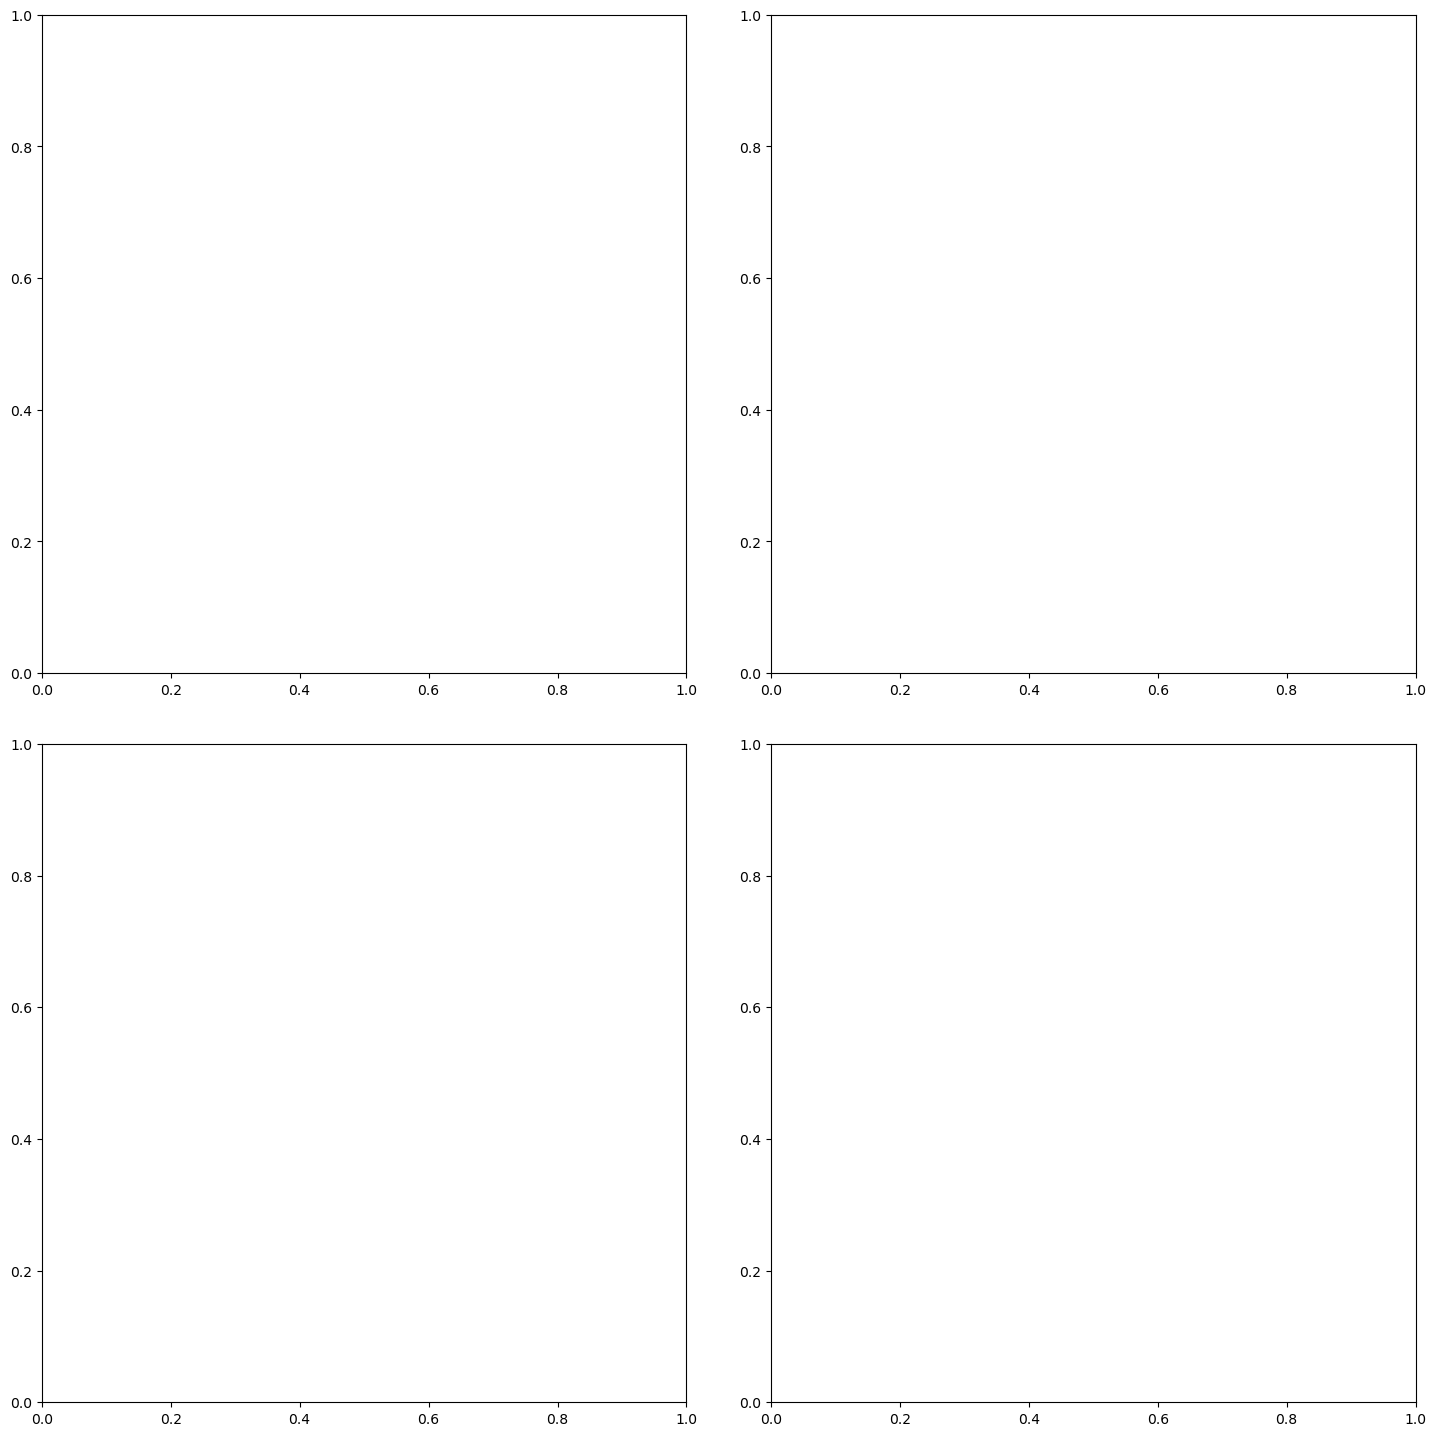

In [30]:
fig, axs = plot_exp2_results(duration, auc_roc_scores, S_rec_errors, X_rec_errors, abbreviations)